# Feature Selection and Correlation Analysis for NO₂ Forecasting

This notebook documents the feature selection process for the Utrecht NO₂ forecasting model.  
We go from raw API data to a clean, reduced feature set that will be used for sequence models (e.g. LSTMs).

**Steps:**
1. Environment Setup and loading raw weather and air quality data.
2. Inspect missing values.
3. Explore feature distributions.
4. Analyse correlations.
5. Explore temporal patterns (hourly and daily).
6. Detect and interpret outliers.


### 1. Environment Setup and loading raw weather and air quality data

In [1]:
import os
from pathlib import Path
import pandas as pd
import sys

PROJECT_ROOT = Path.cwd().parent
print(f"Project root: {PROJECT_ROOT}")
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
from src.data.api_requests import fetch_weather_data, fetch_air_quality_data
from src.data.analysis import (assess_missing_data, plot_missing_heatmap,
                               summarize_distributions, plot_histograms,
                               compute_correlation_matrix, plot_correlation_heatmap,
                               correlations_with_target,
                               diurnal_profile, weekly_profile,
                               detect_outliers_zscore, detect_outliers_iqr)
from src.utils.cfg import load_config



Project root: /Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction


In [ ]:
print(Path.cwd())

cfg = load_config("configs/config_analysis.yaml")
   
fetch_weather_data(cfg)
fetch_air_quality_data(cfg)

/Users/arthurreuss/code/Arthurreuss/Python/RUG/AIE/NO2_Prediction
[WEATHER] Fetching utrecht (52.0908, 5.1222) from 2016-01-02 to 2024-12-31
[WEATHER] Saved 78888 rows to data/analysis/raw/weather/utrecht_weather_2016-01-02_to_2024-12-31.csv
[AIR] Fetching utrecht (52.0908, 5.1222) from 2016-01-02 to 2024-12-31
[AIR] Saved 78888 rows to data/analysis/raw/air_quality/utrecht_air_quality_2016-01-02_to_2024-12-31.csv


In [3]:
loc = list(cfg["api_requests"]["locations"].keys())[0]
start_date = cfg["api_requests"]["time"]["start_date"]
end_date = cfg["api_requests"]["time"]["end_date"]
raw_dir = cfg["api_requests"]["raw_dir"]

aq = pd.read_csv(f"{raw_dir}/air_quality/{loc}_air_quality_{start_date}_to_{end_date}.csv", parse_dates=["time"])
wx = pd.read_csv(f"{raw_dir}/weather/{loc}_weather_{start_date}_to_{end_date}.csv", parse_dates=["time"])

df = pd.merge(wx, aq, on=["time", "location"], how="inner")
assert len(df) == len(wx) == len(aq), "Rows were dropped during merge!"

### 2. Inspect missing values

The columns carbon_dioxide, methane, uv_index, uv_index_clear_sky, aerosol_optical_depth, and ammonia were dropped due to excessive missing values (up to 98%). The dataset start year was set to 2016 to ensure complete coverage for key pollutants like carbon monoxide and sulphur dioxide.

=== Missing data summary (sorted by missing_pct) ===
                                        dtype  n_missing  missing_pct
methane                               float64      77281        97.96
carbon_dioxide                        float64      77281        97.96
uv_index_clear_sky                    float64      57745        73.20
uv_index                              float64      57745        73.20
aerosol_optical_depth                 float64      57745        73.20
ammonia                               float64      17521        22.21
soil_moisture_100_to_255cm            float64          0         0.00
soil_temperature_7_to_28cm            float64          0         0.00
soil_temperature_28_to_100cm          float64          0         0.00
soil_temperature_100_to_255cm         float64          0         0.00
soil_moisture_0_to_7cm                float64          0         0.00
soil_moisture_7_to_28cm               float64          0         0.00
soil_moisture_28_to_100cm            

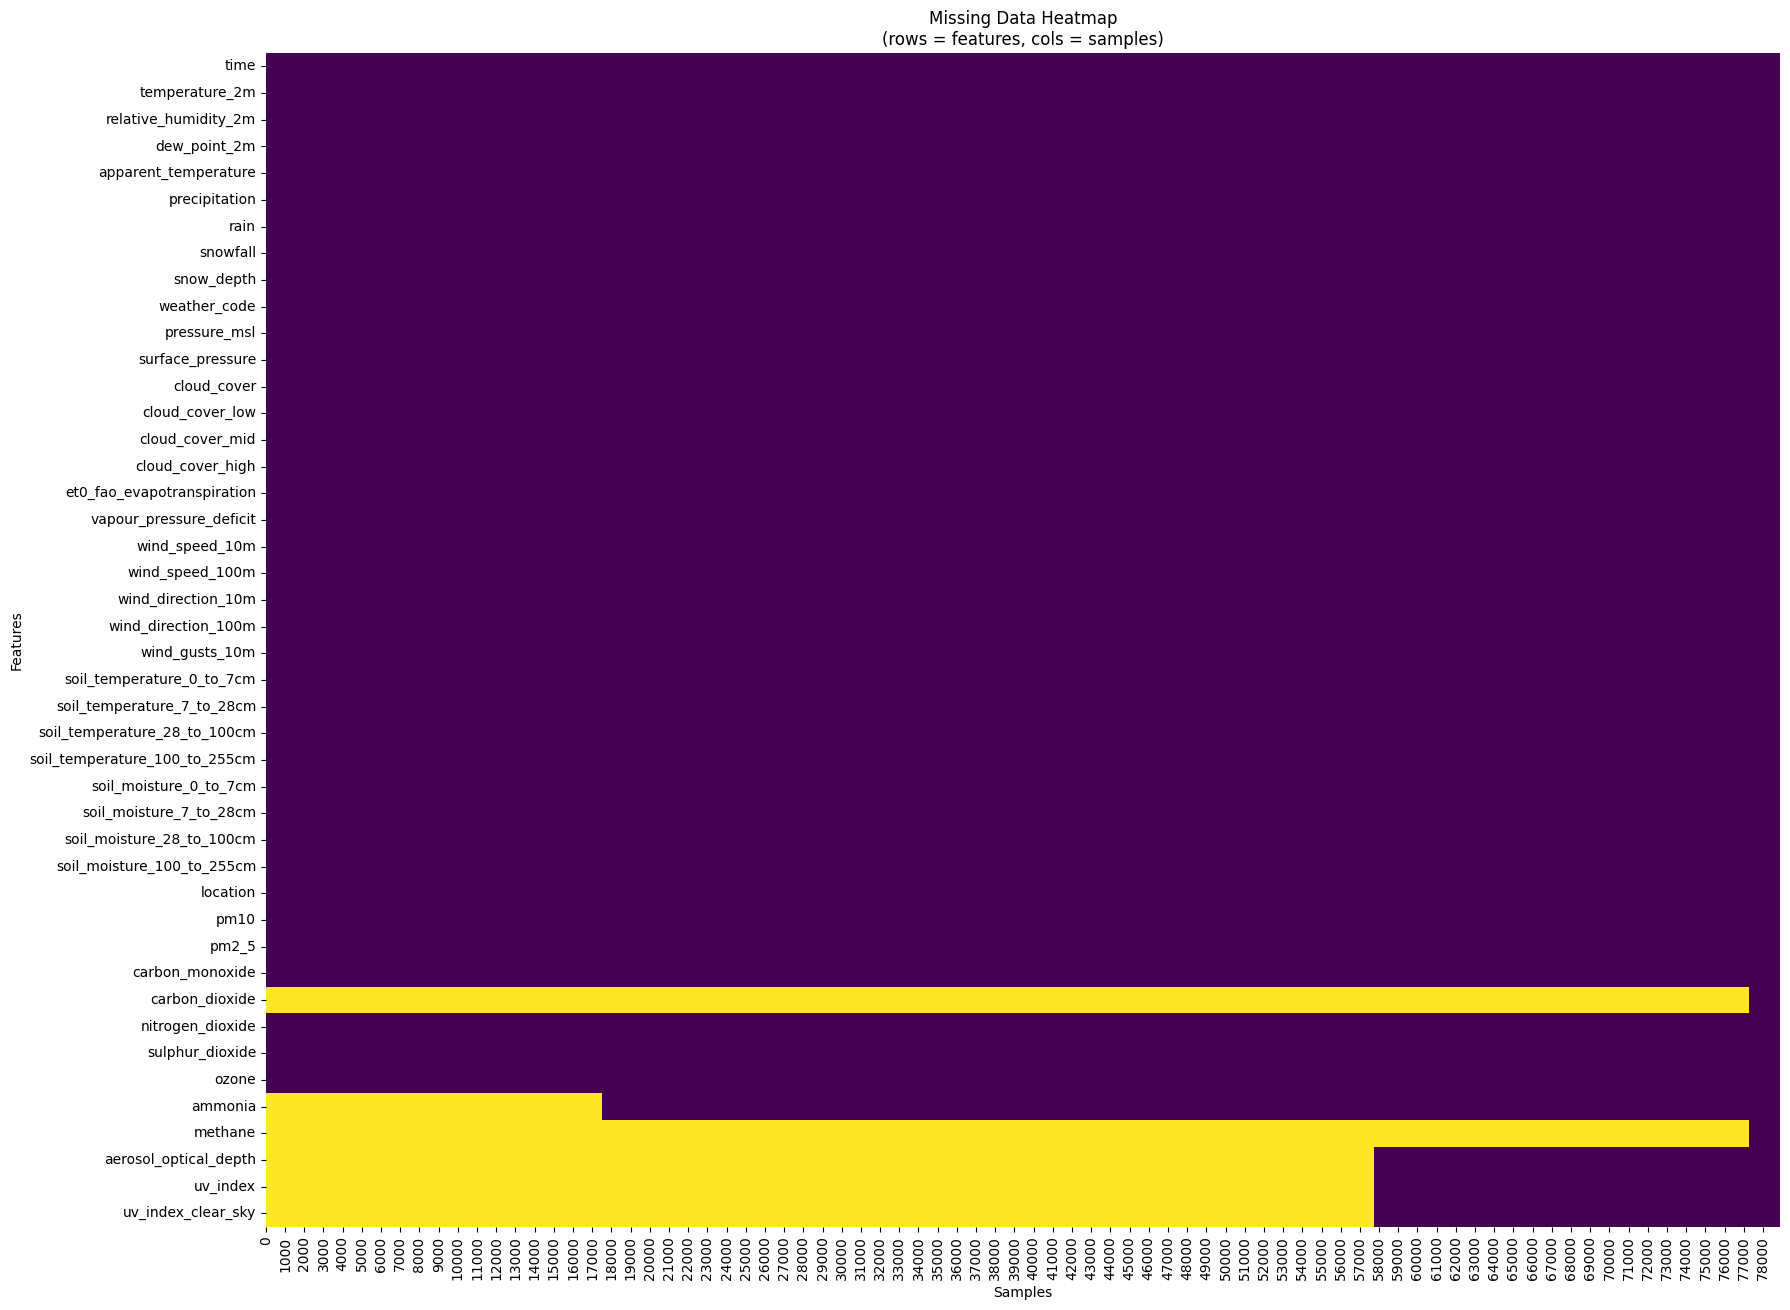

In [4]:
missing_summary = assess_missing_data(df)
plot_missing_heatmap(df)

### 3. Explore feature distributions.

Snow data is extremely rare in this dataset and is unlikely to provide meaningful predictive value. All other features appear acceptable; although some are heavily skewed, but this is not an issue for an LSTM-based model.

=== Distribution summary (numeric columns) ===
                                 count         mean         std       min  \
temperature_2m                 78888.0    11.191198    6.582094   -11.100   
relative_humidity_2m           78888.0    79.934794   13.841019    25.000   
dew_point_2m                   78888.0     7.560613    5.611153   -18.400   
apparent_temperature           78888.0     8.704225    8.037438   -16.100   
precipitation                  78888.0     0.102704    0.375972     0.000   
rain                           78888.0     0.099708    0.370178     0.000   
snowfall                       78888.0     0.002099    0.038708     0.000   
snow_depth                     78888.0     0.000959    0.008373     0.000   
weather_code                   78888.0    12.672168   21.056657     0.000   
pressure_msl                   78888.0  1015.295878   10.434616   968.600   
surface_pressure               78888.0  1014.078453   10.417916   967.400   
cloud_cover                  

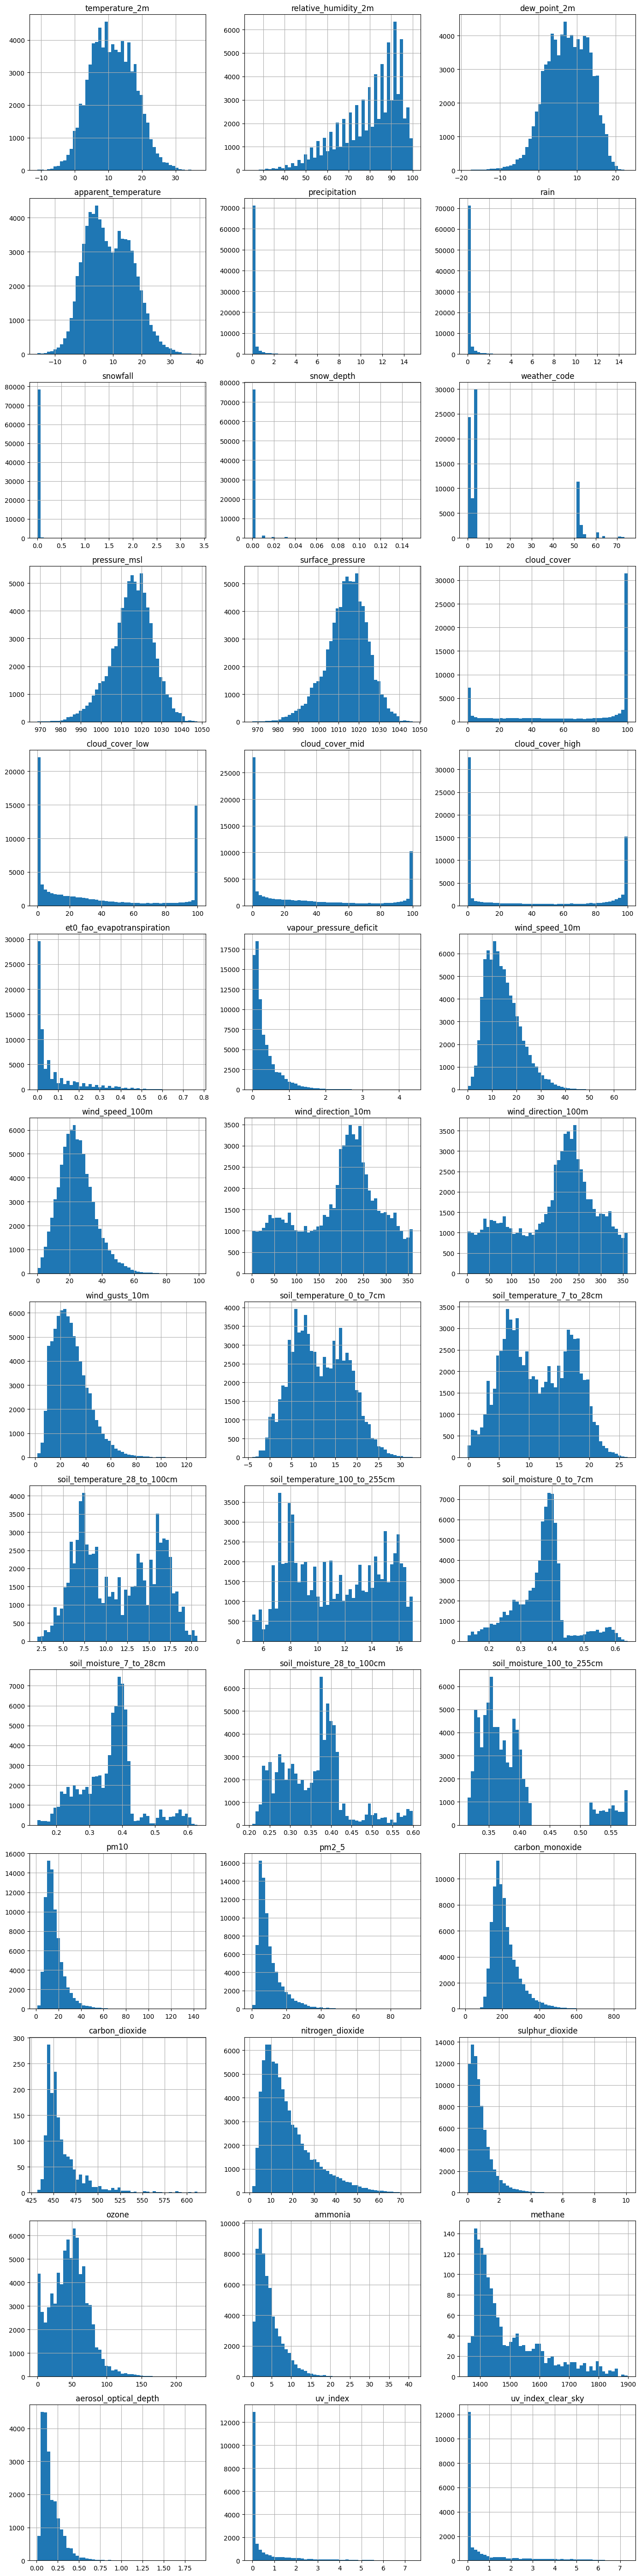

In [5]:
dist_summary = summarize_distributions(df)
plot_histograms(df)

### 4. Analyse correlations.

##### Feature Selection Summary for NO₂ Forecast Model

| Feature                                  | KEEP / DROP          | Reason                                               |
| ---------------------------------------- | -------------------- | ---------------------------------------------------- |
| **nitrogen_dioxide**                     | **KEEP**             | Target variable                                      |
| **pm10, pm2_5**                          | **KEEP**             | Strong co-pollutants from traffic and combustion     |
| **carbon_monoxide**                      | **KEEP**             | Traffic tracer, improves NO₂ prediction              |
| **ozone**                                | **KEEP**             | Photochemical counterpart; anti-correlated with NO₂  |
| **sulphur_dioxide**                      | **KEEP**             | Industrial emission marker; episodic signal          |
| **ammonia**, **aerosol_optical_depth**, **uv_index**, **uv_index_clear_sky**, **carbon_dioxide, methane**             | **DROP**             | Data incomplete, mostly missing values             |
| **temperature_2m**                       | **KEEP**             | Key thermodynamic driver                             |
| **apparent_temperature**                 | **DROP**             | Redundant with temperature + dew point               |
| **dew_point_2m**                         | **KEEP**             | Absolute humidity signal                             |
| **relative_humidity_2m**                 | **KEEP**             | Complements dew point via saturation %               |
| **soil_temperature***                    | **DROP**             | Slow-varying, irrelevant to NO₂                      |
| **soil_moisture***                       | **DROP**             | Same – no mechanistic relevance                      |
| **wind_speed_10m**                       | **KEEP**             | Main pollutant dispersion driver                     |
| **wind_direction_10m**                   | **KEEP (TRANSFORM)** | Encode as sin/cos to avoid circularity               |
| **wind_speed_100m, wind_direction_100m** | **DROP**             | Less relevant for ground-level NO₂                   |
| **wind_gusts_10m**                       | **KEEP**             | Adds turbulence information beyond speed             |
| **precipitation**                        | **KEEP**             | Governs pollutant washout                            |
| **rain**                                 | **DROP**             | Nearly identical to precipitation                    |
| **snowfall, snow_depth**                 | **DROP**             | Zero-dominant, no value in Utrecht                   |
| **cloud_cover_high**                     | **KEEP**             | Best predictor of radiation shielding affecting NO₂  |
| **cloud_cover, low, mid**                | **DROP**             | Less predictive, redundant                           |
| **pressure_msl**                         | **KEEP**             | Standardized pressure, relates to inversion trapping |
| **surface_pressure**                     | **DROP**             | Duplicate of pressure_msl                            |
| **weather_code**                         | **DROP**             | Categorical, already encoded via continuous vars     |
| **vapour_pressure_deficit**              | **KEEP**             | Key drying / thermodynamic driver                    |
| **et0_fao_evapotranspiration**           | **KEEP**             | Different physical process than VPD, complementary   |


=== Pearson correlation matrix (numeric features) ===
                               temperature_2m  relative_humidity_2m  \
temperature_2m                       1.000000             -0.477307   
relative_humidity_2m                -0.477307              1.000000   
dew_point_2m                         0.890715             -0.031953   
apparent_temperature                 0.986135             -0.390877   
precipitation                        0.012699              0.148508   
rain                                 0.025500              0.146303   
snowfall                            -0.084443              0.030361   
snow_depth                          -0.212420              0.026331   
weather_code                        -0.005676              0.173766   
pressure_msl                        -0.046899             -0.091502   
surface_pressure                    -0.044596             -0.092494   
cloud_cover                         -0.052897              0.209576   
cloud_cover_low        

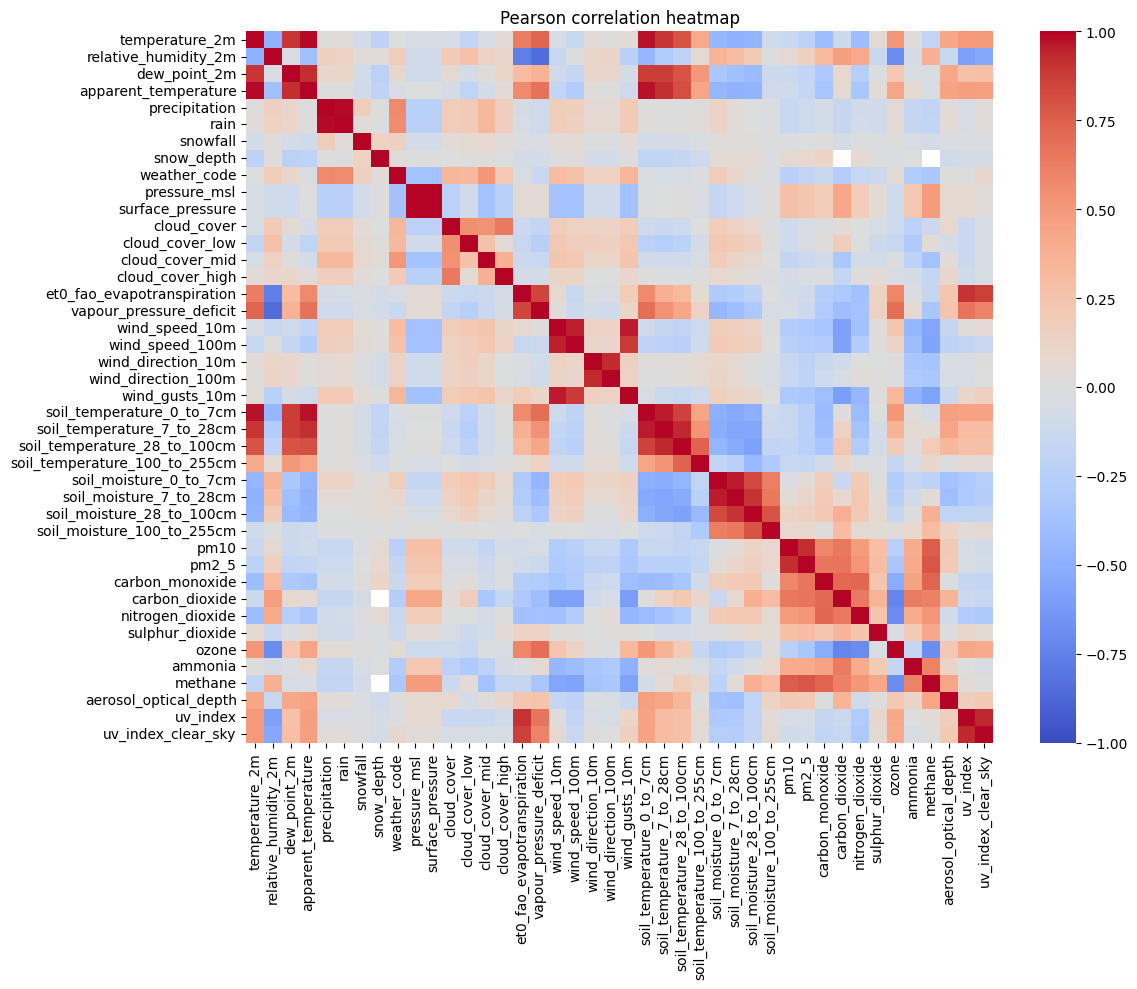

=== Pearson correlations with target 'nitrogen_dioxide' ===
carbon_monoxide                  0.724006
ozone                           -0.695866
carbon_dioxide                   0.643241
pm2_5                            0.520622
methane                          0.513497
pm10                             0.486784
wind_gusts_10m                  -0.447052
soil_temperature_0_to_7cm       -0.418902
relative_humidity_2m             0.417503
temperature_2m                  -0.409202
ammonia                          0.402968
wind_speed_10m                  -0.380885
et0_fao_evapotranspiration      -0.378125
vapour_pressure_deficit         -0.373848
soil_temperature_7_to_28cm      -0.361487
apparent_temperature            -0.333699
uv_index_clear_sky              -0.310331
uv_index                        -0.296426
soil_temperature_28_to_100cm    -0.287912
wind_speed_100m                 -0.285533
dew_point_2m                    -0.262421
sulphur_dioxide                  0.254323
soil_moisture_7_

In [6]:
corr_matrix = compute_correlation_matrix(df)
plot_correlation_heatmap(df)
corr_with_no2 = correlations_with_target(df, target_col="nitrogen_dioxide")

### 5. Explore temporal patterns (hourly and daily).

##### Diurnal Profile (Mean per Hour of Day)
| Feature                              | Behavior                                                            | Interpretation                                                                                                 |
| ------------------------------------ | ------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| **NO₂**                              | Clear **double-peak** pattern – morning (~8 AM) and evening (~8 PM) | Classic traffic signature due to commute times. Strong diurnal structure  |
| **PM10, PM2.5**                      | Mild diurnal variability with afternoon peaks                       | Secondary formation during warm hours + slower peak from activities (e.g. heating, road dust).                 |
| **Ozone**                            | Inverse to NO₂: **lowest in early morning**, peaks at **14–17h**    | Photochemical formation tied to sunlight; confirms that UV and temperature drive chemistry.                    |
| **CO**                               | Tracks NO₂ but more muted variations                                | Traffic pattern as well, but lower volatility as CO disperses slower.                                          |
| **Sulfur dioxide**          | Minor variation                                                     | Weak diurnal drivers – likely dominated by background sources.                                                 |
| **Temperature, dew point, humidity** | Temperature: rises to afternoon peak; Humidity: inversely follows   | Perfect cyclic structure. Both relevant for predicting atmospheric stability and reaction rates.               |
| **Wind speed and gusts**             | Increases through day, peaks in afternoon                           | Typical boundary-layer behavior; daytime mixing reduces pollution after morning peaks.                         |
| **Cloud cover high**                 | Slightly higher at night, moderate during day                       | Good indicator of radiation blocking.            |
| **VPD & ET₀**                        | Both rise sharply midday and fall at night                          | Confirm complementarity: VPD measures moisture deficit; ET₀ captures evaporative power.                        |

##### Weekly Profile (Mean per Day, Mon–Sun)
| Feature                         | Behavior                                         | Interpretation                                                                   |
| ------------------------------- | ------------------------------------------------ | -------------------------------------------------------------------------------- |
| **NO₂**                         | Highest midweek (Tue–Thu), decreases on weekends | Classic weekday traffic effect – confirms needing weekly context.                |
| **Ozone**                       | Opposite trend: higher on weekends               | “Weekend ozone effect” – lower NOₓ allows more ozone formation. Well documented. |
| **CO, PM2.5, PM10**             | Slight midweek peaks                             | Follows NO₂: traffic and combustion sources.                                     |
| **Temperature, wind, humidity** | No consistent weekly cycle                       | Meteorology doesn't track weekly patterns – seasonal drivers dominate.           |
| **Cloud cover high**  | No weekly pattern                                | Expected because cloud cover and sunlight aren't human-driven.                   |

We add cyclical time features (hour and day encodings) because the temporal profiles reveal strong diurnal and weekly patterns in pollutant concentrations that the model would otherwise need to learn implicitly, requiring longer context windows and more data.


In [7]:
kept_features = [
    # Target
    "nitrogen_dioxide",

    # Co-pollutants
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "ozone",
    "sulphur_dioxide",

    # Meteorological variables
    "temperature_2m",
    "dew_point_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",

    # Hydrological and radiative
    "precipitation",
    "cloud_cover_high",
    "pressure_msl",
    "vapour_pressure_deficit",
    "et0_fao_evapotranspiration"
]


diurnal = diurnal_profile(df, time_col="time", cols=kept_features)
weekly = weekly_profile(df, time_col="time", cols=kept_features)

=== Diurnal profile (mean by hour of day) ===
      nitrogen_dioxide       pm10      pm2_5  carbon_monoxide      ozone  \
hour                                                                       
0            19.687435  16.848890  10.777548       222.913051  40.774262   
1            18.141953  16.750137  10.978004       214.919075  40.128993   
2            17.082963  16.633891  10.998388       209.751141  39.166413   
3            16.285458  16.432948  10.868299       204.978400  38.563127   
4            15.911591  16.309340  10.834195       201.679039  37.381199   
5            16.294068  16.274719  10.822300       201.488287  36.075449   
6            18.186462  16.433435  10.953636       208.039246  34.000304   
7            20.956739  16.693915  11.239671       222.991786  32.426225   
8            21.955248  16.739306  11.344874       233.761789  33.908427   
9            20.754457  16.492668  11.336599       232.381503  38.023426   
10           18.493702  16.100213  11.1282

### 6. Detect and interpret outliers.

The detected outliers primarily reflect meaningful, real-world conditions (e.g., extreme weather events or pollution episodes) rather than data errors, so no feature removal or aggressive clipping is warranted at this stage.

In [8]:
# 5. Anomalies
kept_features = [
    # Target
    "nitrogen_dioxide",

    # Co-pollutants
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "ozone",
    "sulphur_dioxide",
    "ammonia",
    "aerosol_optical_depth",

    # Meteorological variables
    "temperature_2m",
    "dew_point_2m",
    "relative_humidity_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",

    # Hydrological and radiative
    "precipitation",
    "cloud_cover_high",
    "pressure_msl",
    "uv_index",
    "vapour_pressure_deficit",
    "et0_fao_evapotranspiration"
]

z_outliers = detect_outliers_zscore(df, cols=kept_features, z_thresh=3.0)
iqr_outliers = detect_outliers_iqr(df, cols=kept_features, iqr_multiplier=1.5)


=== Z-score Outlier Summary (threshold = 3.0) ===
                            n_outliers  pct_outliers
et0_fao_evapotranspiration        1738          2.20
vapour_pressure_deficit           1562          1.98
precipitation                     1560          1.98
pm2_5                             1487          1.88
sulphur_dioxide                   1484          1.88
pm10                              1425          1.81
carbon_monoxide                   1332          1.69
nitrogen_dioxide                  1081          1.37
ammonia                            930          1.18
wind_gusts_10m                     698          0.88
wind_speed_10m                     678          0.86
uv_index                           666          0.84
ozone                              617          0.78
relative_humidity_2m               454          0.58
pressure_msl                       404          0.51
dew_point_2m                       325          0.41
aerosol_optical_depth              319          